# CCPi CIL and SIRF

* CIL is an heterogeneous collection of software codes for Computed Tomography
* Beam Hardening
* Framework for iterative reconstruction algorithm development in Python 
* Denoising toolkit for proximal splitting algorithms (C/CUDA)
* Digital Volume correlation (for strain)
* Visualisation (3D Viewer)

## Optimisation

In [1]:
'''
GRAPPA reconstruction with an iterative algorithm from CIL: illustrates
the use of AcquisitionModel in CIL optimisation 

Usage:
  grappa_and_cil.py [--help | options]

Options:
  -f <file>, --file=<file>    raw data file
                              [default: simulated_MR_2D_cartesian_Grappa2.h5]
  -p <path>, --path=<path>    path to data files, defaults to data/examples/MR
                              subfolder of SIRF root folder
'''

## CCP PETMR Synergistic Image Reconstruction Framework (SIRF)
## Copyright 2015 - 2019 Rutherford Appleton Laboratory STFC.
## Copyright 2015 - 2019 University College London.
##
## This is software developed for the Collaborative Computational
## Project in Positron Emission Tomography and Magnetic Resonance imaging
## (http://www.ccppetmr.ac.uk/).
##
## Licensed under the Apache License, Version 2.0 (the "License");
##   you may not use this file except in compliance with the License.
##   You may obtain a copy of the License at
##       http://www.apache.org/licenses/LICENSE-2.0
##   Unless required by applicable law or agreed to in writing, software
##   distributed under the License is distributed on an "AS IS" BASIS,
##   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
##   See the License for the specific language governing permissions and
##   limitations under the License.


import sirf
from sirf.Utilities import existing_filepath
from sirf.Utilities import error
from sirf.Utilities import show_3D_array
from sirf.Gadgetron import examples_data_path
from sirf.Gadgetron import AcquisitionData, ImageData
from sirf.Gadgetron import AcquisitionModel
from sirf.Gadgetron import AcquisitionDataProcessor
from sirf.Gadgetron import CartesianGRAPPAReconstructor
from sirf.Gadgetron import CoilSensitivityData


from cil.optimisation.functions import LeastSquares
from cil.optimisation.functions import ZeroFunction
from cil.optimisation.algorithms import FISTA, CGLS, GD
from cil.plugins.ccpi_regularisation.functions import FGP_TV#, TGV, LLT_ROF, Diff4th
from cil.framework import DataContainer as cilDataContainer
from cil.optimisation.operators import LinearOperator

import numpy
import time
# %matplotlib notebook
import matplotlib.pyplot as plt
import os




## Prepare the Data and AcquisitionModel

In [ ]:
# process command-line options
data_file = 'simulated_MR_2D_cartesian_Grappa2.h5'
data_path = None
if data_path is None:
    data_path = examples_data_path('MR')
    
data_path = os.path.join('/home/jovyan/work/SIRF-Exercises/data', 'MR', 'PTB_ACRPhantom_GRAPPA')
data_file = 'ptb_resolutionphantom_GRAPPA4_ismrmrd.h5'



# locate the input data file
input_file = existing_filepath(data_path, data_file)
print (input_file)


# acquisition data will be read from an HDF file input_data
acq_data = AcquisitionData(input_file)


# pre-process acquisition data
print('---\n pre-processing acquisition data...')
# the following function runs a GadgetChain data processor
# preprocessed_data = preprocess_acquisition_data(acq_data)
gadget_chain = ['NoiseAdjustGadget', \
                'AsymmetricEchoAdjustROGadget', \
                'RemoveROOversamplingGadget']
ap = AcquisitionDataProcessor( gadget_chain )
ap.set_input( acq_data )
ap.process()
preprocessed_data = ap.get_output()

### Undersampling
ky_index = preprocessed_data.get_ISMRMRD_info('kspace_encode_step_1')

# Define an undersampling factor
R = 4

# Define the number of fully sampled k-space points in the k-space centre
N_ctr = 10

# and your k-space centre was in the middle, so 
ky0_index = len(ky_index)//2

ky_index_subset =  numpy.arange(ky0_index-N_ctr//2, ky0_index+N_ctr//2)

ky_index_subset = numpy.concatenate((ky_index_subset, numpy.arange(start=0, stop=len(ky_index), step=R)), axis=0)

ky_index_subset = numpy.unique(ky_index_subset)

acq_new = preprocessed_data.new_acquisition_data(empty=True)

# Create raw data
# for jnd in range(len(ky_index_subset)):
#     cacq = preprocessed_data.acquisition(ky_index_subset[jnd])
#     acq_new.append_acquisition(cacq)

# for i,el in enumerate(preprocessed_data.acquisition):
#     print (i,el)

for i, ky in enumerate(ky_index):
    if ky in ky_index_subset:
        print(i,ky)
        

acq_new.sort()     

# perform reconstruction
recon = CartesianGRAPPAReconstructor()
recon.set_input( preprocessed_data )
recon.compute_gfactors( False )
print('---\n reconstructing...')
recon.process()
# for undersampled acquisition data GRAPPA computes Gfactor images
# in addition to reconstructed ones
image_data = recon.get_output()

image_array = image_data.as_array()
title = 'Reconstructed image data (magnitude)'
show_3D_array(abs(image_array), suptitle = title, label = 'slice', \
              xlabel = 'samples', ylabel = 'readouts', show = False)

# compute coil sensitivity maps
csms = CoilSensitivityData()
print('---\n sorting acquisition data...')
preprocessed_data.sort()
print('---\n computing sensitivity maps...')
csms.calculate( preprocessed_data )

In [ ]:
# process command-line options
data_file = 'simulated_MR_2D_cartesian_Grappa2.h5'
data_path = None
if data_path is None:
    data_path = examples_data_path('MR')
    
data_path = os.path.join('/home/jovyan/work/SIRF-Exercises/data', 'MR', 'PTB_ACRPhantom_GRAPPA')
data_file = 'ptb_resolutionphantom_GRAPPA4_ismrmrd.h5'



# locate the input data file
input_file = existing_filepath(data_path, data_file)
print (input_file)


# acquisition data will be read from an HDF file input_data
acq_data = AcquisitionData(input_file)


# pre-process acquisition data
print('---\n pre-processing acquisition data...')
# the following function runs a GadgetChain data processor
# preprocessed_data = preprocess_acquisition_data(acq_data)
gadget_chain = ['NoiseAdjustGadget', \
                'AsymmetricEchoAdjustROGadget', \
                'RemoveROOversamplingGadget']
ap = AcquisitionDataProcessor( gadget_chain )
ap.set_input( acq_data )
ap.process()
preprocessed_data = ap.get_output()

### Undersampling
ky_index = preprocessed_data.get_ISMRMRD_info('kspace_encode_step_1')

# Define an undersampling factor
R = 4

# Define the number of fully sampled k-space points in the k-space centre
N_ctr = 20

# and your k-space centre was in the middle, so 

Nky=256
ky0_index = Nky//2
ky_index_subset =  numpy.arange(ky0_index-N_ctr//2, ky0_index+N_ctr//2)

ky_index_subset = numpy.concatenate((ky_index_subset, numpy.arange(start=0, stop=Nky, step=R)), axis=0)

ky_index_subset = numpy.unique(ky_index_subset)

acq_new = preprocessed_data.new_acquisition_data(empty=True)

# Create raw data
# for jnd in range(len(ky_index_subset)):
#     cacq = preprocessed_data.acquisition(ky_index_subset[jnd])
#     acq_new.append_acquisition(cacq)

# for i,el in enumerate(preprocessed_data.acquisition):
#     print (i,el)

for i, ky in enumerate(ky_index):
    if ky in ky_index_subset:
        print(i,ky)
        cacq = preprocessed_data.acquisition(i)
        acq_new.append_acquisition(cacq)
        
acq_new.sort()     
preprocessed_data = acq_new

# perform reconstruction
recon = CartesianGRAPPAReconstructor()
recon.set_input( preprocessed_data )
recon.compute_gfactors( False )
print('---\n reconstructing...')
recon.process()
# for undersampled acquisition data GRAPPA computes Gfactor images
# in addition to reconstructed ones
image_data = recon.get_output()

image_array = image_data.as_array()
title = 'Reconstructed image data (magnitude)'
show_3D_array(abs(image_array), suptitle = title, label = 'slice', \
              xlabel = 'samples', ylabel = 'readouts', show = False)

# compute coil sensitivity maps
csms = CoilSensitivityData()
print('---\n sorting acquisition data...')
preprocessed_data.sort()
print('---\n computing sensitivity maps...')
csms.calculate( preprocessed_data )

In [4]:
preprocessed_data.acquisition

<bound method AcquisitionData.acquisition of <sirf.Gadgetron.AcquisitionData object at 0x7fd32e0240b0>>

In [5]:
# create acquisition model based on the acquisition parameters
# stored in preprocessed_data and image parameters stored in
# image_data
acq_model = AcquisitionModel( preprocessed_data, image_data )
acq_model.set_coil_sensitivity_maps( csms )

# use the acquisition model (forward projection) to simulate acquisition data
simulated_data = acq_model.forward( image_data )

# CIL/SIRF integration

Create the objective function as Norm2square
$$
c || A x - b ||^2
$$
where $c$ is a constant, $A$ is the linear operator and $b$ are the data.

You may need to close Figure 1 window to continue...


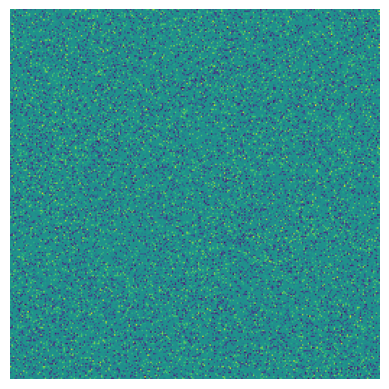

0

In [6]:
# create a Norm2square objective function
# c || Ax - b ||^2
norm2sq = LeastSquares( A = acq_model , b = preprocessed_data , c = 1)
# create a random initialisation image by shuffling the real
# image data. 
x_init = image_data.copy()
x = x_init.as_array().flatten()
numpy.random.shuffle(x)
x = numpy.reshape(x, x_init.shape)
x_init.fill(x)
del x

show_3D_array(x_init.asarray().real)

The linear operator $A$, the AcquisitionModel, should satisfy the dot test: 

$Ax_0\times y_0 = y_0 \times A^Tx_0$

In [7]:
assert LinearOperator.dot_test(acq_model)

In [8]:
lipschitz = LinearOperator.PowerMethod(acq_model, 10, x_init)

norm2sq.L = lipschitz  
print ("Lipschitz " , norm2sq.L)

Lipschitz  0.9887382144442598


/opt/conda/lib/python3.12/site-packages/cil/optimisation/functions/LeastSquares.py:113: UserWarning: You should set the Lipschitz constant with calculate_Lipschitz().
  warnings.warn("You should set the Lipschitz constant with calculate_Lipschitz().")


In [9]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

interactive_plot = False

# create a Gradient Descent algorithm which minimises norm2sq
gd = GD(initial=x_init, 
           f=norm2sq, step_size=lipschitz/3.)

  0%|          | 0/50 [00:00<?, ?it/s]

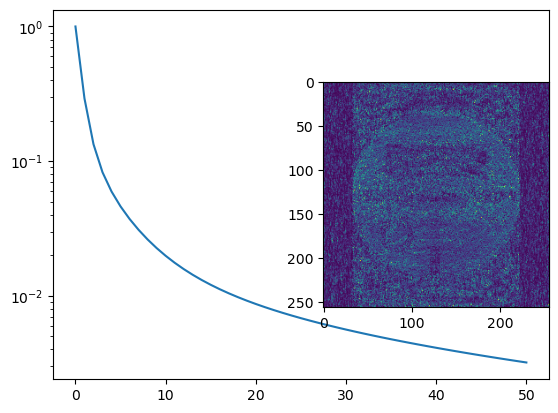

In [10]:

pixval = []
gadgval = image_data.as_array()[0][46][160]


gd.update_objective_interval = 1
gd.run(50,verbose=True)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.semilogy([val/gd.loss[0] for val in gd.loss])
im = fig.add_subplot(122)
im.imshow(abs(gd.get_output().as_array()[0]))
fig.show()
    

In [11]:
#show_3D_array(gd.get_output().as_array().real, suptitle='Gradient Descent (magnitude)')

#%%
# USE FISTA with Regularisation   
no_regulariser = ZeroFunction()
# create a regulariser with the Factory
regulariser = FGP_TV( 
                    alpha=3,
                    max_iteration=300,
                    tolerance=1e-5,
                    isotropic=True,
                    nonnegativity=0,
                    device='cpu')
options = {'tol': 1e-4, 'iter': 10, 'memopt':False}

norm2sq.L = lipschitz*3.
# create a FISTA algorithm instance
fista = FISTA(initial=x_init, f=norm2sq, g=regulariser)

/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


  0%|          | 0/20 [00:00<?, ?it/s]

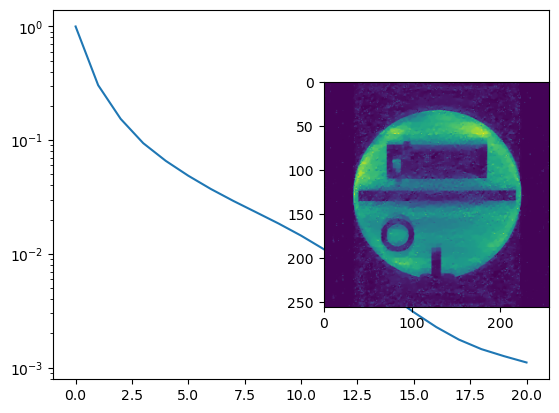

In [12]:
fpixval = []
#%%
# run FISTA



fista.update_objective_interval = 1
fista.run(20)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.semilogy([val/fista.loss[0] for val in fista.loss])
im = fig.add_subplot(122)
im.imshow(abs(fista.get_output().as_array()[0]))
fig.show()
    

In [13]:
fista_noreg = FISTA(initial=x_init, f=norm2sq, g=no_regulariser)
fpixval = []
#%%
# run FISTA

  0%|          | 0/20 [00:00<?, ?it/s]

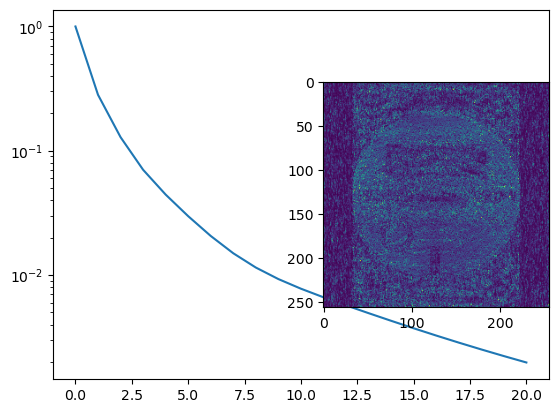

In [14]:

fista_noreg.run(20)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.semilogy([val/fista_noreg.loss[0] for val in fista_noreg.loss])
im = fig.add_subplot(122)
im.imshow(abs(fista_noreg.get_output().as_array()[0]))
fig.show()
    

[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


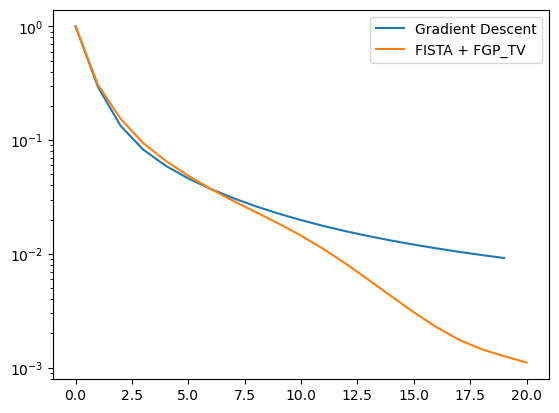

In [15]:
# plot convergence
print (gd._iteration)
fig = plt.figure()
ax = plt.semilogy([gd.loss[i]/max(gd.loss) for i in range(20)], label='Gradient Descent')
#ax = plt.plot([el/max(fista_noreg.loss) for el in fista_noreg.loss], label='FISTA')
ax = plt.semilogy([el/max(fista.loss) for el in fista.loss], label='FISTA + FGP_TV')
plt.legend()
plt.show()

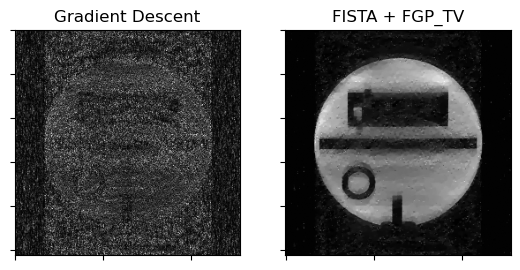

In [16]:
#%%
# plot the results
fig = plt.figure()
#ax1 = plt.subplot(1,4,1)
#plt.imshow(abs(image_data.as_array()[0]), cmap='gray')
#plt.clim(0, 5)
#ax1.set_title('Initial Data')
#ax2 = plt.subplot(1,4,2)
ax2 = plt.subplot(1,2,1)
plt.imshow(abs(gd.solution.asarray()[0]), cmap='gray')
# plt.clim(0, 1.)
ax2.set_title('Gradient Descent')
ax2.set_yticklabels([])
ax2.set_xticklabels([])
#ax2 = plt.subplot(1,4,3)
#ax2 = plt.subplot(1,2,1)
#plt.imshow(abs(fista_noreg.get_output().as_array()[0]), cmap='gray')
#plt.clim(0, 5)
#ax2.set_title('FISTA no reg')
#ax2 = plt.subplot(1,4,4)
ax2 = plt.subplot(1,2,2)
ax2.set_yticklabels([])
ax2.set_xticklabels([])
plt.imshow(abs(fista.solution.asarray()[0]), cmap='gray')
# plt.clim(0, 1.)
ax2.set_title('FISTA + FGP_TV')
plt.show()
#%%


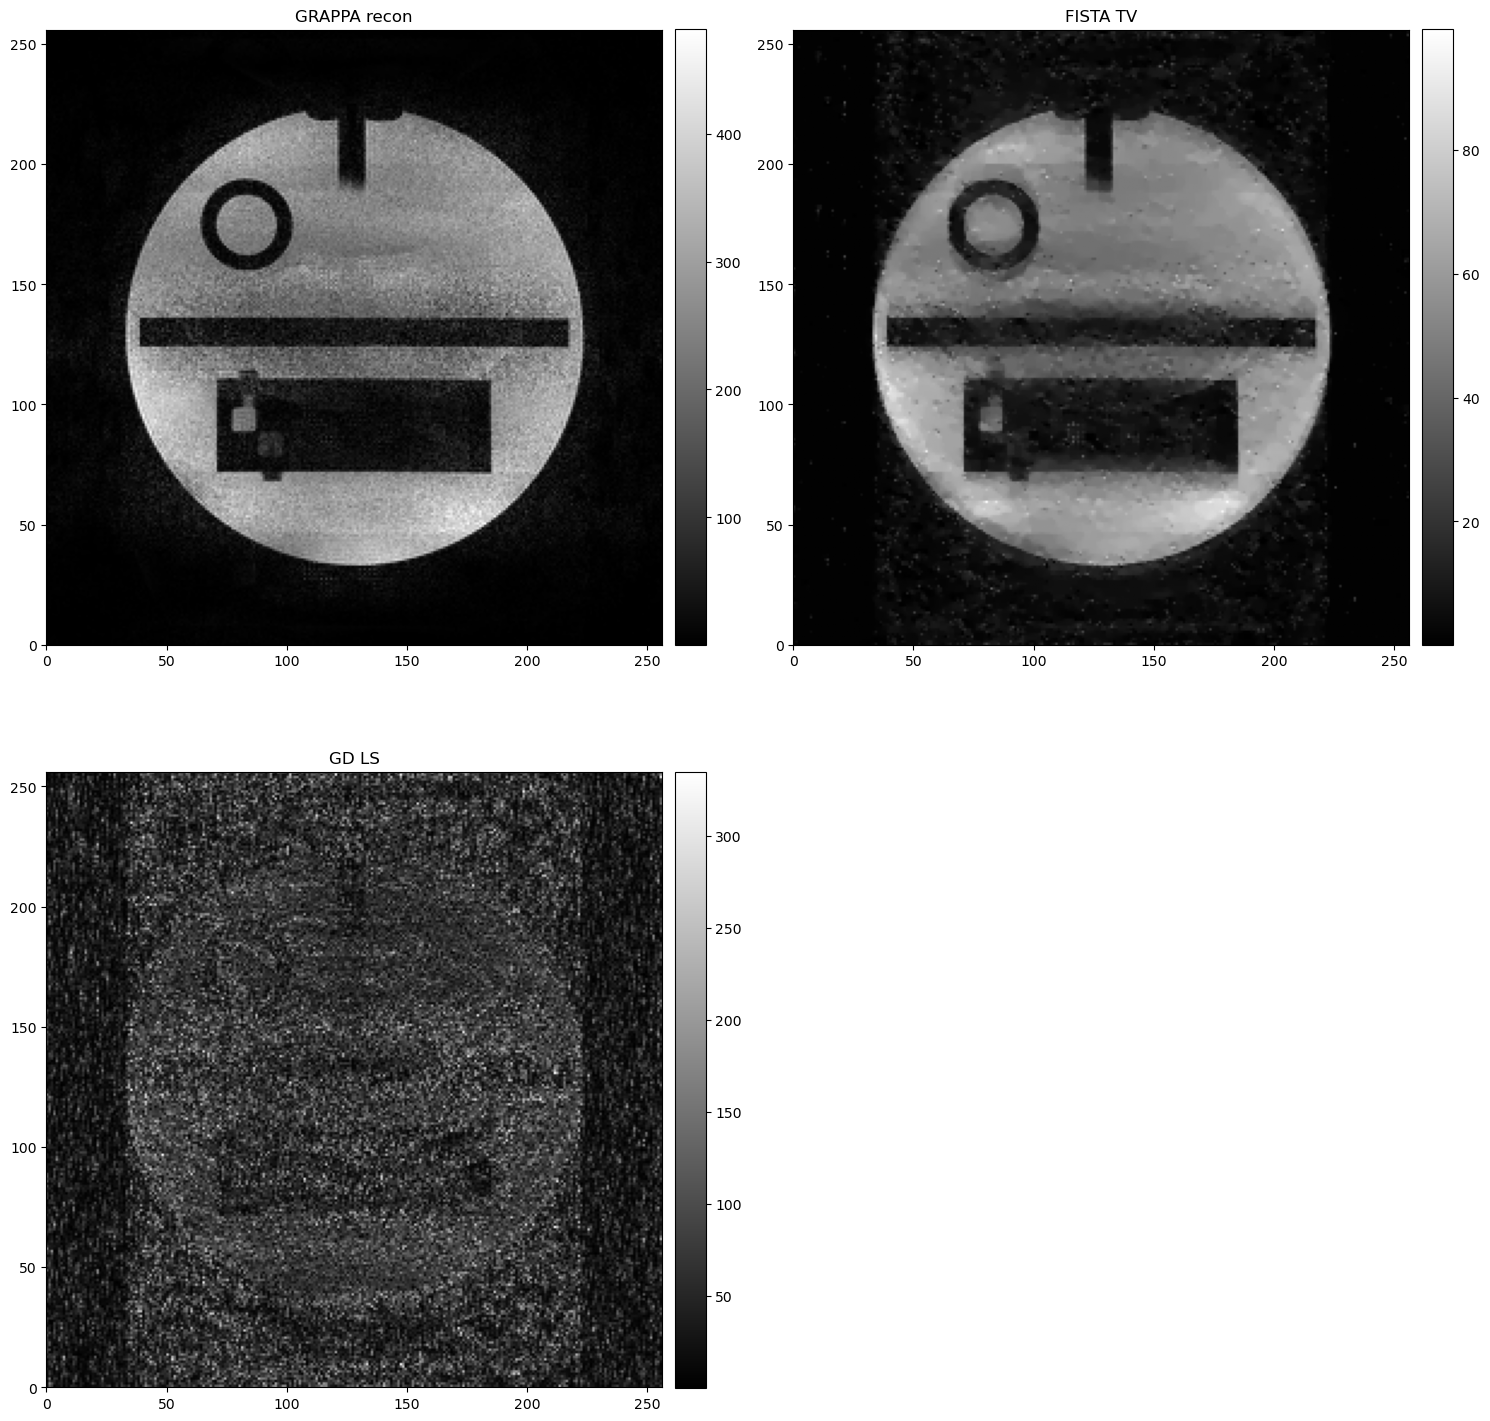

In [17]:
from cil.utilities.display import show2D
import numpy as np

solutions = [recon.get_output(), fista.solution, gd.solution]

show2D([np.abs(el.asarray()[0]) for el in solutions],
       title = ['GRAPPA recon', 'FISTA TV', 'GD LS'], cmap='gray', fix_range=False)

In [18]:
print (gadgval)

fista_noreg.update_objective_interval = 5
fista_noreg.run(10)




(-248.71992-299.55338j)


 70%|#######   | 21/30 [00:00<?, ?it/s]

In [19]:
cgls = CGLS(initial=x_init, operator=acq_model, data=preprocessed_data)

  0%|          | 0/12 [00:00<?, ?it/s]

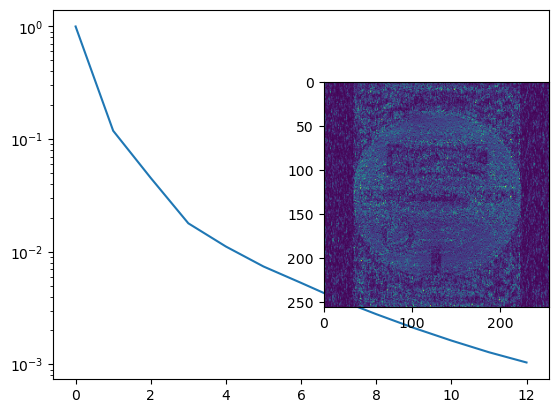

In [20]:
cgls.run(12)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.semilogy([val/cgls.loss[0] for val in cgls.loss])
im = fig.add_subplot(122)
im.imshow(abs(cgls.solution.asarray()[0]))
fig.show()